### Dependencies

In [2]:
# %pip install pandas numpy seaborn matplotlib scikit-learn wfdb


### Imports

In [3]:
from pathlib import Path
import sys
import os
import random
from collections import Counter

import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    CUDB_PATH, VFDB_PATH, OUTPUT_DIR, FS, RANDOM_SEED, TEST_FRACTION,
    MIN_MAJORITY, WINDOW_CONFIGS, EXCLUDED_RECORDS,
)
from src.io import load_signal, get_annotations, scan_record
from src.annotations import cudb_episodes, vfdb_episodes, record_metrics, find_nan_blocks
from src.labeling import (
    class_breakdown_pct, CLASS_MAP_VFDB, vfdb_label_intervals,
    cudb_label_intervals, evidence_based_transitional_regions,
    count_spike_events, cudb_label_intervals_v2,
    flag_special_handling_cudb, flag_special_handling_vfdb, vfdb_unclosed,
)
from src.windowing import window_record, build_windowed_dataset

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
cudb_path = CUDB_PATH

with open(os.path.join(cudb_path, 'RECORDS')) as f:
    records = [line.strip() for line in f if line.strip()]
cudb_set = set(records)

print(f"Found {len(records)} records:", records)


Found 35 records: ['cu01', 'cu02', 'cu03', 'cu04', 'cu05', 'cu06', 'cu07', 'cu08', 'cu09', 'cu10', 'cu11', 'cu12', 'cu13', 'cu14', 'cu15', 'cu16', 'cu17', 'cu18', 'cu19', 'cu20', 'cu21', 'cu22', 'cu23', 'cu24', 'cu25', 'cu26', 'cu27', 'cu28', 'cu29', 'cu30', 'cu31', 'cu32', 'cu33', 'cu34', 'cu35']


In [5]:
rates = set()
for rec in records:
    r = wfdb.rdrecord(os.path.join(cudb_path, rec))
    rates.add(r.fs)

print("Distinct sampling rates found across all CUDB records:", rates)


Distinct sampling rates found across all CUDB records: {250}


In [6]:
sample_record = wfdb.rdrecord(os.path.join(cudb_path, records[0]))
fs = sample_record.fs
assert fs == FS, f"Expected configured FS={FS}, found {fs}"
print("fs read from file:", fs)


fs read from file: 250


In [7]:
vfdb_path = VFDB_PATH
records_file = os.path.join(vfdb_path, 'RECORDS')
print("RECORDS file exists:", os.path.exists(records_file))


RECORDS file exists: True


In [8]:
with open(os.path.join(vfdb_path, 'RECORDS')) as f:
    vfdb_records = [line.strip() for line in f if line.strip()]

print(f"Found {len(vfdb_records)} VFDB records:", vfdb_records)


Found 22 VFDB records: ['418', '419', '420', '421', '422', '423', '424', '425', '426', '427', '428', '429', '430', '602', '605', '607', '609', '610', '611', '612', '614', '615']


In [9]:
sample_record_vfdb = wfdb.rdrecord(os.path.join(vfdb_path, vfdb_records[0]))
fs_vfdb = sample_record_vfdb.fs
assert fs_vfdb == FS, f"Expected configured FS={FS}, found {fs_vfdb}"
print("VFDB fs read from file:", fs_vfdb)


VFDB fs read from file: 250


## 13. Cross-Database Summary Table
Pulls every record from both databases through the Chapter 2 episode-extraction and metrics functions (`cudb_episodes`, `vfdb_episodes`, `record_metrics`) into one comparison table, then progressively enriches it with signal-quality and episode-context flags.

### 13.1 Base summary table

In [10]:
rows = []

# CUDB records
for rec in records:
    signal, record_len = load_signal(rec, cudb_path)
    episodes, record_len, unclosed = cudb_episodes(rec, cudb_path)
    metrics = record_metrics(signal, episodes, fs)
    rows.append(dict(db='CUDB', record=rec, length_s=round(record_len/fs, 1),
                      n_episodes=len(episodes), unclosed=unclosed, **metrics))

# VFDB records
for rec in vfdb_records:
    signal, record_len = load_signal(rec, vfdb_path)
    episodes, record_len, unclosed = vfdb_episodes(rec, vfdb_path)
    metrics = record_metrics(signal, episodes, fs)
    rows.append(dict(db='VFDB', record=rec, length_s=round(record_len/fs, 1),
                      n_episodes=len(episodes), unclosed=unclosed, **metrics))

summary_df = pd.DataFrame(rows)
summary_df


,db,record,length_s,n_episodes,unclosed,nan_count,nan_pct,clip_count,total_episode_duration,shock_boundaries
0,CUDB,cu01,508.9,1,False,0,0.00,0,294.7,0
1,CUDB,cu02,508.9,0,False,538,0.42,182,0.0,0
2,CUDB,cu03,508.9,1,False,4,0.00,101,43.2,0
3,CUDB,cu04,508.9,4,False,0,0.00,69,272.2,4
4,CUDB,cu05,508.9,1,False,52,0.04,34,87.6,1
5,CUDB,cu06,508.9,2,False,62,0.05,64,137.1,1
6,CUDB,cu07,508.9,1,False,0,0.00,0,326.9,0
7,CUDB,cu08,508.9,1,False,496,0.39,1703,82.5,0
8,CUDB,cu09,508.9,1,False,1099,0.86,0,57.4,1
9,CUDB,cu10,508.9,1,False,453,0.36,23,192.4,0


### 13.2 VFDB — how often is NOISE right next to a dangerous episode?
Checks whether each episode has a `NOISE` segment starting within 5s of its start or end, then folds that into a per-record ratio column on `summary_df`.

In [11]:
def vfdb_noise_near_episode(rec, window_s=5):
    """Count how many of this record's dangerous episodes have a (NOISE segment
    starting within window_s seconds of the episode's start or end."""
    samples, _, notes = get_annotations(rec, vfdb_path)
    segments = [(s, n) for s, n in zip(samples, notes) if n]
    noise_samples = [s for s, n in segments if n == '(NOISE']

    episodes, record_len, unclosed = vfdb_episodes(rec, vfdb_path)
    count = 0
    for s, e in episodes:
        near = any(abs(ns - e) <= window_s*fs or abs(ns - s) <= window_s*fs for ns in noise_samples)
        if near:
            count += 1
    return count


def vfdb_noise_ratio(rec):
    """Fraction of a VFDB record's episodes that have (NOISE within 5s of a boundary."""
    episodes, _, _ = vfdb_episodes(rec, vfdb_path)
    if len(episodes) == 0:
        return None
    n_near = vfdb_noise_near_episode(rec)
    return round(n_near / len(episodes), 2)


for rec in vfdb_records:
    episodes, _, _ = vfdb_episodes(rec, vfdb_path)
    n_near = vfdb_noise_near_episode(rec)
    if len(episodes) > 0:
        print(f"{rec}: {n_near}/{len(episodes)} episodes have NOISE within 5s of a boundary")


418: 0/60 episodes have NOISE within 5s of a boundary
419: 6/33 episodes have NOISE within 5s of a boundary
420: 3/3 episodes have NOISE within 5s of a boundary
421: 1/50 episodes have NOISE within 5s of a boundary
422: 4/5 episodes have NOISE within 5s of a boundary
423: 1/1 episodes have NOISE within 5s of a boundary
424: 2/2 episodes have NOISE within 5s of a boundary
425: 1/1 episodes have NOISE within 5s of a boundary
426: 4/10 episodes have NOISE within 5s of a boundary
427: 0/1 episodes have NOISE within 5s of a boundary
428: 0/3 episodes have NOISE within 5s of a boundary
429: 0/5 episodes have NOISE within 5s of a boundary
430: 1/13 episodes have NOISE within 5s of a boundary
602: 0/4 episodes have NOISE within 5s of a boundary
605: 1/1 episodes have NOISE within 5s of a boundary
607: 0/6 episodes have NOISE within 5s of a boundary
609: 0/2 episodes have NOISE within 5s of a boundary
610: 0/1 episodes have NOISE within 5s of a boundary
611: 0/2 episodes have NOISE within 5s of

In [12]:
summary_df['noise_near_episode_ratio'] = summary_df.apply(
    lambda row: vfdb_noise_ratio(row['record']) if row['db'] == 'VFDB' else None,
    axis=1
)

summary_df.to_csv(OUTPUT_DIR / 'episode_summary_v2.csv', index=False)
summary_df


,db,record,length_s,n_episodes,unclosed,nan_count,nan_pct,clip_count,total_episode_duration,shock_boundaries,noise_near_episode_ratio
0,CUDB,cu01,508.9,1,False,0,0.00,0,294.7,0,NaN
1,CUDB,cu02,508.9,0,False,538,0.42,182,0.0,0,NaN
2,CUDB,cu03,508.9,1,False,4,0.00,101,43.2,0,NaN
3,CUDB,cu04,508.9,4,False,0,0.00,69,272.2,4,NaN
4,CUDB,cu05,508.9,1,False,52,0.04,34,87.6,1,NaN
5,CUDB,cu06,508.9,2,False,62,0.05,64,137.1,1,NaN
6,CUDB,cu07,508.9,1,False,0,0.00,0,326.9,0,NaN
7,CUDB,cu08,508.9,1,False,496,0.39,1703,82.5,0,NaN
8,CUDB,cu09,508.9,1,False,1099,0.86,0,57.4,1,NaN
9,CUDB,cu10,508.9,1,False,453,0.36,23,192.4,0,NaN


### 13.3 Choosing signal-quality flag thresholds for CUDB

In [13]:
# look at the distribution of nan_pct and clip_count across CUDB before picking thresholds
cudb_rows = summary_df[summary_df['db'] == 'CUDB']
print(cudb_rows[['nan_pct', 'clip_count']].describe())


         nan_pct   clip_count
count  35.000000    35.000000
mean    0.800857   954.142857
std     1.388737  1624.560196
min     0.000000     0.000000
25%     0.010000    66.500000
50%     0.270000   374.000000
75%     0.935000   990.000000
max     5.850000  7932.000000


### 13.4 Flagging records that need special handling — first pass
Combines signal-quality issues (NaNs, clipping) and unclosed episodes into a single flag.

### 13.5 Refining the flag: separating "unclosed" from signal quality
`unclosed` is a label-continuity assumption, not a signal-quality problem — splitting it out into its own independent column instead of folding it into `needs_special_handling`.

In [14]:
summary_df['needs_special_handling'] = summary_df.apply(
    lambda row: flag_special_handling_cudb(row) if row['db'] == 'CUDB' else flag_special_handling_vfdb(row),
    axis=1
)

# `unclosed` is tracked independently from signal quality.
summary_df['unclosed'] = summary_df.apply(
    lambda row: row['unclosed'] if row['db'] == 'CUDB' else vfdb_unclosed(row['record'], vfdb_path),
    axis=1
)

print("--- needs_special_handling (signal quality) ---")
print(summary_df[summary_df['needs_special_handling']][['db','record','nan_pct','clip_count']])
print("\nTotal:", summary_df['needs_special_handling'].sum())

print("\n--- unclosed (label-continuity assumption) ---")
print(summary_df[summary_df['unclosed']][['db','record','n_episodes']])
print("\nTotal:", summary_df['unclosed'].sum())

print("\n--- overlap (both flags) ---")
print(summary_df[summary_df['needs_special_handling'] & summary_df['unclosed']][['db','record']])

summary_df.to_csv(OUTPUT_DIR / 'episode_summary_v4.csv', index=False)


--- needs_special_handling (signal quality) ---
      db record  nan_pct  clip_count
7   CUDB   cu08     0.39        1703
10  CUDB   cu11     1.01        1003
13  CUDB   cu14     0.01        1016
18  CUDB   cu19     1.26         860
19  CUDB   cu20     1.29         930
20  CUDB   cu21     1.69         887
22  CUDB   cu23     1.90        1867
23  CUDB   cu24     1.82        2822
25  CUDB   cu26     5.79        7932
26  CUDB   cu27     1.79        1747
29  CUDB   cu30     5.85        5494
33  CUDB   cu34     0.00        1913
35  VFDB    418     0.00           0
36  VFDB    419     0.00           3
38  VFDB    421     0.00           3
52  VFDB    610     0.00           0
56  VFDB    615     0.00           0

Total: 17

--- unclosed (label-continuity assumption) ---
      db record  n_episodes
14  CUDB   cu15           1
18  CUDB   cu19           2
19  CUDB   cu20           1
27  CUDB   cu28           1
28  CUDB   cu29           1
29  CUDB   cu30           3
30  CUDB   cu31           1
34 

## 14. Final Label Scheme: 3 Classes

After every rhythm label in both databases was worked through (visual inspection, RR-interval
coefficient of variation, transition-sequence analysis, and duration checks), three classes
were settled on: **Normal**, **Dangerous**, and **Transitional**.

A binary (Normal vs. Dangerous) scheme was considered first, matching the original "detect any
non-normal rhythm" framing, but a third class was argued for by the data itself: several labels
(`ASYS`, `VER`, CUDB's `~`) were consistently found to show no organized beat structure,
and were seen sitting in the sequence between a dangerous rhythm and recovery.

A 4th "Noise" class was also considered, to separate physiologically unstable-but-readable
signal from genuinely corrupted signal (clipping/dropped samples), but was decided against —
both were found to be rare enough already that splitting further would leave too few examples
per class.

**Normal**
- VFDB: `N`, `PM`, `B`, `BI`, `NOD`
- CUDB: unlabeled regions before the first marker, `N` beats outside episodes/`~` regions

**Dangerous**
- VFDB: `VT`, `SVTA`, `VF`, `VFL`, `VFIB`, `AFIB`
- CUDB: `[`/`]` bracket episodes (unclosed episodes are treated as continuing to the end of
  the recording)

**Transitional**
- VFDB: `ASYS`, `VER`, `HGEA`, `SBR`, `NSR`
- CUDB: `~`-flagged regions

**Excluded (quality flags, not rhythm labels):** VFDB `NOISE`, CUDB `|`

Judgment calls worth remembering:
- `AFIB` was placed in Dangerous, despite organized (not chaotic) beats being observed —
  it's treated as a sustained abnormal rhythm requiring attention, not an unstable
  in-between state.
- `B`/`BI` was placed in Normal, since bigeminy alone isn't typically considered acutely
  dangerous.
- `HGEA` was placed in Transitional rather than Dangerous, despite high beat-to-beat
  variability being measured (CV up to 1.37) — in its before/after neighbor counts, a
  return to `N` was seen far more often (12-13x) than a transition into `VT`/`VF` (4-5x),
  so it's treated as a transient instability rather than a precursor to worse rhythm.
- `SBR` and `NSR` were folded into Transitional rather than Normal, because only 2
  instances of each were found, and both failed the regularity check (CV of 0.31-0.82 was
  measured, far above the ~0.01 found for `N`) — too unreliable to be trusted as
  representative of their nominal label.

This chapter builds the class mapping in two passes: a first, simpler pass for both databases
(14.2-14.8), then a deeper look at CUDB specifically once the simple `~`-based approach turned
out to miss real structure in the data (14.9 onward), ending in a revised builder used for the
final breakdown.

### 14.1 Chapter helper: class-breakdown percentages
The \"% of record time in each class\" computation gets reused several times below (once per record, then again over `cu26`/`cu30`, then again over all of CUDB) — pulled out here.

### 14.2 VFDB — label-to-class mapping

### 14.3 CUDB — label-to-class mapping (v1, `~`-based)\n\nFirst pass: episodes (`[`/`]`) are Dangerous, `~`-flagged stretches are Transitional, everything else is Normal.

In [15]:
def cudb_label_intervals(rec):
    samples, symbols, _ = get_annotations(rec, cudb_path)
    _, record_len = load_signal(rec, cudb_path)
    episodes, _, unclosed = cudb_episodes(rec, cudb_path)
    tilde_samples = [s for s, sym in zip(samples, symbols) if sym == '~']

    intervals = []
    prev_end = 0
    for (s, e) in episodes:
        if s > prev_end:
            has_tilde = any(prev_end <= t < s for t in tilde_samples)
            intervals.append((prev_end, s, 'Transitional' if has_tilde else 'Normal'))
        intervals.append((s, e, 'Dangerous'))
        prev_end = e
    if prev_end < record_len:
        has_tilde = any(prev_end <= t < record_len for t in tilde_samples)
        intervals.append((prev_end, record_len, 'Transitional' if has_tilde else 'Normal'))
    return intervals, record_len


### 14.4 Sanity-checking both interval builders on one record each

In [16]:
print(vfdb_label_intervals('430', vfdb_path))
print()
print(cudb_label_intervals('cu26'))


([(np.int64(28), np.int64(51903), 'Normal'), (np.int64(51903), np.int64(53211), 'Dangerous'), (np.int64(53211), np.int64(85615), 'Normal'), (np.int64(93134), np.int64(94423), 'Normal'), (np.int64(94423), np.int64(94903), 'Dangerous'), (np.int64(94903), np.int64(98596), 'Normal'), (np.int64(98596), np.int64(99557), 'Normal'), (np.int64(99557), np.int64(118057), 'Dangerous'), (np.int64(120807), np.int64(131153), 'Dangerous'), (np.int64(131153), np.int64(134519), 'Transitional'), (np.int64(134519), np.int64(138076), 'Transitional'), (np.int64(138076), np.int64(156576), 'Transitional'), (np.int64(156576), np.int64(157923), 'Dangerous'), (np.int64(157923), np.int64(163192), 'Transitional'), (np.int64(163192), np.int64(169179), 'Dangerous'), (np.int64(169179), np.int64(170237), 'Transitional'), (np.int64(170237), np.int64(172275), 'Transitional'), (np.int64(172275), np.int64(173891), 'Dangerous'), (np.int64(173891), np.int64(175429), 'Transitional'), (np.int64(175429), np.int64(193891), 'Dan

### 14.5 VFDB — checking excluded/unmapped time doesn't leave large unexplained gaps

In [17]:
def total_gap_time(rec):
    intervals, record_len = vfdb_label_intervals(rec, vfdb_path)
    covered = sum(e - s for s, e, _ in intervals)
    gap = record_len - covered
    return gap / fs, record_len / fs

for rec in vfdb_records:
    gap_s, total_s = total_gap_time(rec)
    if gap_s > 0:
        print(f"{rec}: {gap_s:.1f}s excluded out of {total_s:.0f}s ({100*gap_s/total_s:.1f}%)")


418: 0.1s excluded out of 2100s (0.0%)
419: 775.8s excluded out of 2100s (36.9%)
420: 497.8s excluded out of 2100s (23.7%)
421: 433.9s excluded out of 2100s (20.7%)
422: 210.5s excluded out of 2100s (10.0%)
423: 563.1s excluded out of 2100s (26.8%)
424: 280.5s excluded out of 2100s (13.4%)
425: 301.0s excluded out of 2100s (14.3%)
426: 481.5s excluded out of 2100s (22.9%)
427: 0.1s excluded out of 2100s (0.0%)
428: 11.6s excluded out of 2100s (0.6%)
429: 190.6s excluded out of 2100s (9.1%)
430: 41.2s excluded out of 2100s (2.0%)
602: 182.3s excluded out of 2100s (8.7%)
607: 0.2s excluded out of 2100s (0.0%)
609: 0.1s excluded out of 2100s (0.0%)
610: 81.5s excluded out of 2100s (3.9%)
611: 0.2s excluded out of 2100s (0.0%)
612: 0.1s excluded out of 2100s (0.0%)
614: 0.3s excluded out of 2100s (0.0%)
615: 0.2s excluded out of 2100s (0.0%)


### 14.6 Investigating record 605's gap — an all-NOISE recording

In [18]:
samples, symbols, notes = get_annotations('605', vfdb_path)
for s, note in zip(samples, notes):
    if note:
        print(f"sample {s} ({s/fs:.1f}s): {note}")


sample 64 (0.3s): (NOISE
sample 411942 (1647.8s): (VT
sample 419115 (1676.5s): (NOISE


### 14.7 Excluding 605 from the VFDB mapping

### 14.8 CUDB — per-record class breakdown, v1

In [19]:
print("--- CUDB class breakdown per record ---")
for rec in records:
    intervals, record_len = cudb_label_intervals(rec)
    pct = class_breakdown_pct(intervals, record_len, fs)
    total_s = record_len / fs
    print(f"{rec}: len={total_s:.0f}s | Normal={pct['Normal']}% Dangerous={pct['Dangerous']}% Transitional={pct['Transitional']}%")


--- CUDB class breakdown per record ---
cu01: len=509s | Normal=42.1% Dangerous=57.9% Transitional=0.0%
cu02: len=509s | Normal=0.0% Dangerous=0.0% Transitional=100.0%
cu03: len=509s | Normal=0.0% Dangerous=8.5% Transitional=91.5%
cu04: len=509s | Normal=46.5% Dangerous=53.5% Transitional=0.0%
cu05: len=509s | Normal=70.5% Dangerous=17.2% Transitional=12.3%
cu06: len=509s | Normal=73.1% Dangerous=26.9% Transitional=0.0%
cu07: len=509s | Normal=35.8% Dangerous=64.2% Transitional=0.0%
cu08: len=509s | Normal=0.0% Dangerous=16.2% Transitional=83.8%
cu09: len=509s | Normal=88.7% Dangerous=11.3% Transitional=0.0%
cu10: len=509s | Normal=62.2% Dangerous=37.8% Transitional=0.0%
cu11: len=509s | Normal=72.9% Dangerous=27.1% Transitional=0.0%
cu12: len=509s | Normal=61.8% Dangerous=38.2% Transitional=0.0%
cu13: len=509s | Normal=5.4% Dangerous=10.7% Transitional=84.0%
cu14: len=509s | Normal=0.0% Dangerous=0.0% Transitional=100.0%
cu15: len=509s | Normal=79.8% Dangerous=20.2% Transitional=0.0%


### 14.9 Is `~`-based Transitional detection actually reliable?
Checking gap distribution by looking at how far apart consecutive `~` markers tend to be — a first check on whether treating the gap between any two `~` markers as \"Transitional\" is a reasonable assumption.

In [20]:
gaps_between_tildes = []
for rec in records:
    samples, symbols, _ = get_annotations(rec, cudb_path)
    tilde_samples = sorted(s for s, sym in zip(samples, symbols) if sym == '~')
    for i in range(1, len(tilde_samples)):
        gap = (tilde_samples[i] - tilde_samples[i-1]) / fs
        gaps_between_tildes.append(gap)

gaps_arr = np.array(gaps_between_tildes)
print("Number of consecutive ~ pairs:", len(gaps_arr))
print("Median gap (s):", np.median(gaps_arr))
print("25th/75th percentile (s):", np.percentile(gaps_arr, [25, 75]))
print("How many gaps are under 10s:", (gaps_arr < 10).sum(), "out of", len(gaps_arr))


Number of consecutive ~ pairs: 127
Median gap (s): 2.208
25th/75th percentile (s): [ 0.854 17.788]
How many gaps are under 10s: 89 out of 127


### 14.10 CUDB — label-to-class mapping (v2, evidence-based)
The `~`-gap distribution above wasn't clean enough to trust a fixed-window heuristic. This builds Transitional regions directly from the same NaN and clipping evidence used back in Chapters 7-8, instead of `~` markers.

### 14.11 Sanity-checking evidence-based regions against known NaN gaps

In [21]:
print(evidence_based_transitional_regions('cu26', cudb_path, fs))
print(evidence_based_transitional_regions('cu27', cudb_path, fs))


[(np.int64(42160), np.int64(42719)), (np.int64(50549), np.int64(54298)), (np.int64(54629), np.int64(62428)), (np.int64(63400), np.int64(66677)), (np.int64(67110), np.int64(72768)), (np.int64(79149), np.int64(79663)), (np.int64(81080), np.int64(81589)), (np.int64(96471), np.int64(96974)), (np.int64(118474), np.int64(119213)), (np.int64(120211), np.int64(121370)), (np.int64(123069), np.int64(124087))]
[(0, np.int64(3374)), (np.int64(3583), np.int64(4749)), (np.int64(79573), np.int64(80295)), (np.int64(82471), np.int64(82975)), (np.int64(84270), np.int64(85020)), (np.int64(106066), np.int64(106577)), (np.int64(110623), np.int64(111183)), (np.int64(117787), np.int64(118288)), (np.int64(118463), np.int64(119538)), (np.int64(122271), np.int64(123639))]


### 14.12 Visualizing episodes vs. evidence-based transitional regions (cu26)

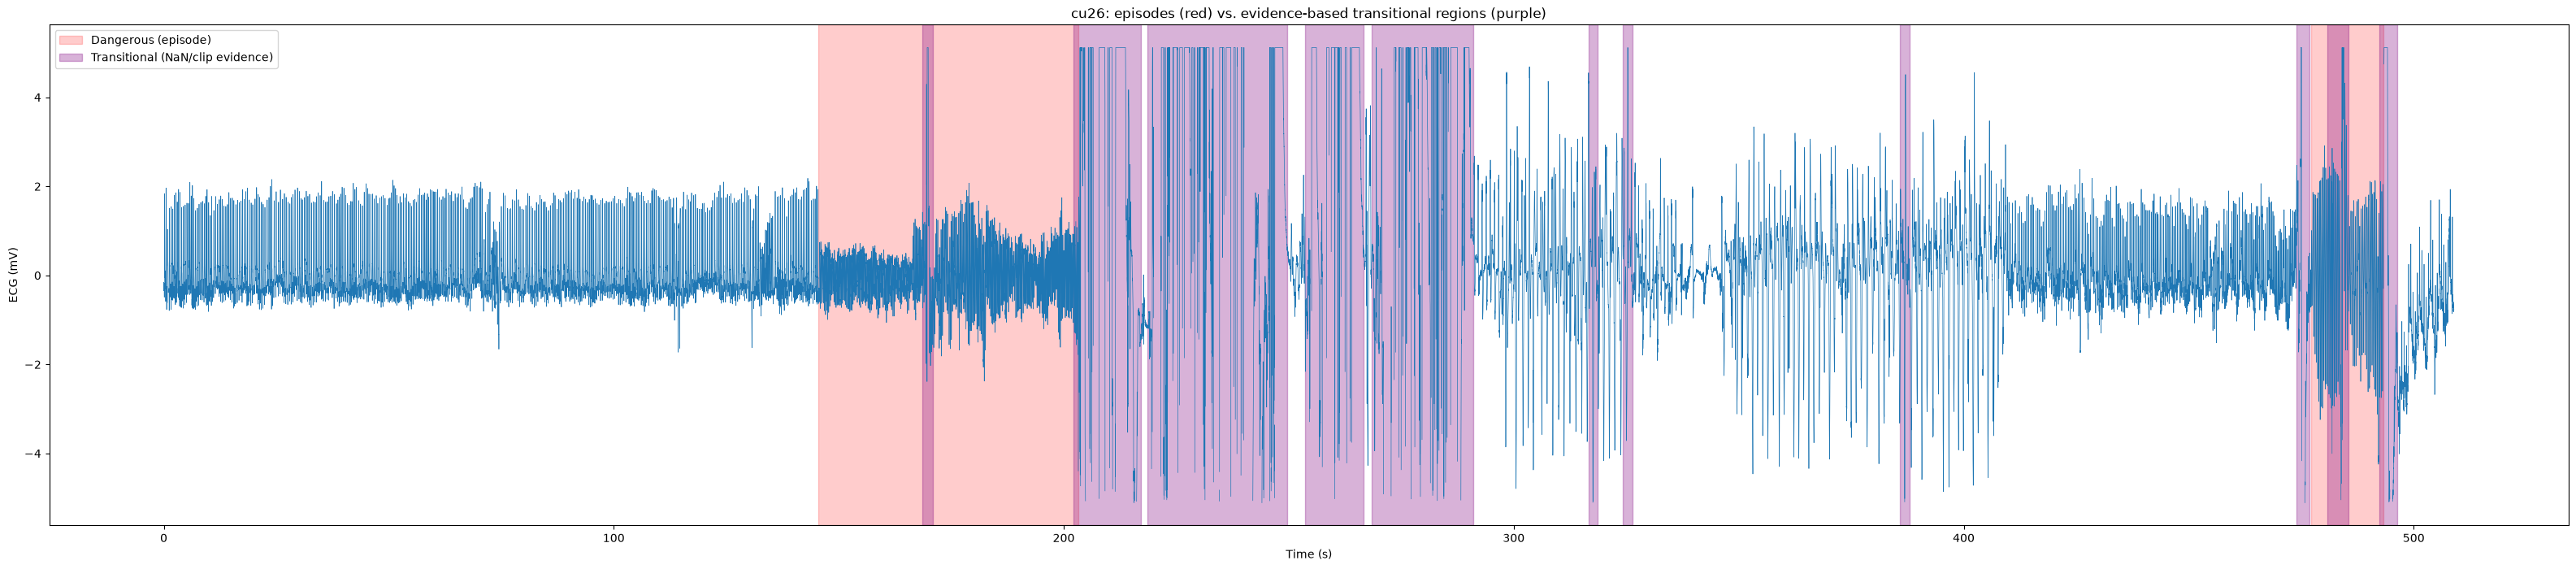

In [22]:
rec = 'cu26'
signal, record_len = load_signal(rec, cudb_path)
episodes, _, _ = cudb_episodes(rec, cudb_path)
transitional_regions = evidence_based_transitional_regions(rec, cudb_path, fs)

time = np.arange(record_len) / fs

plt.figure(figsize=(40, 8))
plt.plot(time, signal, linewidth=0.5)
for i, (s, e) in enumerate(episodes):
    plt.axvspan(s/fs, e/fs, color='red', alpha=0.2, label='Dangerous (episode)' if i == 0 else None)
for i, (s, e) in enumerate(transitional_regions):
    plt.axvspan(s/fs, e/fs, color='purple', alpha=0.3, label='Transitional (NaN/clip evidence)' if i == 0 else None)
plt.xlabel('Time (s)')
plt.ylabel('ECG (mV)')
plt.title(f'{rec}: episodes (red) vs. evidence-based transitional regions (purple)')
plt.legend()
plt.show()


### 14.13 Zooming into a region where an episode and a transitional region overlap

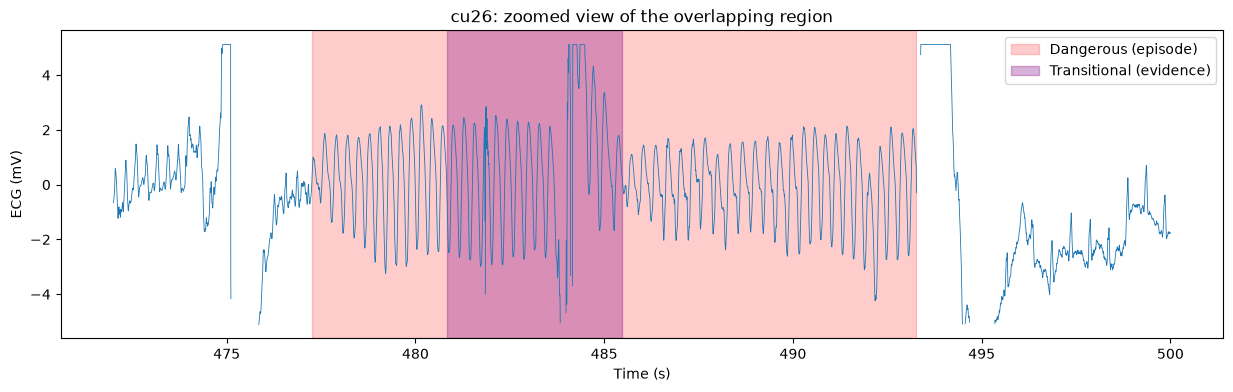

In [23]:
zoom_start, zoom_end = 118000, 125000  # around episode 2 and the overlapping region
plt.figure(figsize=(15, 4))
plt.plot(np.arange(zoom_start, zoom_end)/fs, signal[zoom_start:zoom_end], linewidth=0.6)
plt.axvspan(119316/fs, 123315/fs, color='red', alpha=0.2, label='Dangerous (episode)')
plt.axvspan(120211/fs, 121370/fs, color='purple', alpha=0.3, label='Transitional (evidence)')
plt.xlabel('Time (s)')
plt.ylabel('ECG (mV)')
plt.title(f'{rec}: zoomed view of the overlapping region')
plt.legend()
plt.show()


### 14.14 Finding every episode / transitional-region overlap across CUDB

In [24]:
overlap_cases = []
for rec in records:
    episodes, _, _ = cudb_episodes(rec, cudb_path)
    regions = evidence_based_transitional_regions(rec, cudb_path, fs)
    for ep_s, ep_e in episodes:
        for r_s, r_e in regions:
            # check if the evidence region overlaps this episode at all
            overlap_start = max(ep_s, r_s)
            overlap_end = min(ep_e, r_e)
            if overlap_start < overlap_end:
                overlap_cases.append((rec, ep_s, ep_e, r_s, r_e, (overlap_end-overlap_start)/fs))

print(f"Total overlapping cases found: {len(overlap_cases)}")
for rec, ep_s, ep_e, r_s, r_e, dur in overlap_cases:
    print(f"{rec}: episode({ep_s/fs:.0f}-{ep_e/fs:.0f}s), evidence-region({r_s/fs:.0f}-{r_e/fs:.0f}s), overlap={dur:.1f}s")


Total overlapping cases found: 130
cu03: episode(466-509s), evidence-region(477-479s), overlap=2.0s
cu04: episode(155-211s), evidence-region(209-211s), overlap=2.3s
cu04: episode(224-244s), evidence-region(242-244s), overlap=2.0s
cu04: episode(255-346s), evidence-region(344-347s), overlap=1.6s
cu04: episode(370-475s), evidence-region(474-476s), overlap=1.5s
cu05: episode(359-446s), evidence-region(445-448s), overlap=1.5s
cu06: episode(184-308s), evidence-region(280-282s), overlap=2.2s
cu06: episode(320-333s), evidence-region(332-336s), overlap=1.4s
cu08: episode(426-509s), evidence-region(485-488s), overlap=3.1s
cu09: episode(239-297s), evidence-region(264-266s), overlap=2.1s
cu09: episode(239-297s), evidence-region(272-275s), overlap=3.2s
cu09: episode(239-297s), evidence-region(285-287s), overlap=2.0s
cu09: episode(239-297s), evidence-region(294-299s), overlap=2.1s
cu10: episode(317-509s), evidence-region(480-485s), overlap=4.4s
cu10: episode(317-509s), evidence-region(488-490s), ove

### 14.15 Zooming into cu30's 31.5s overlap

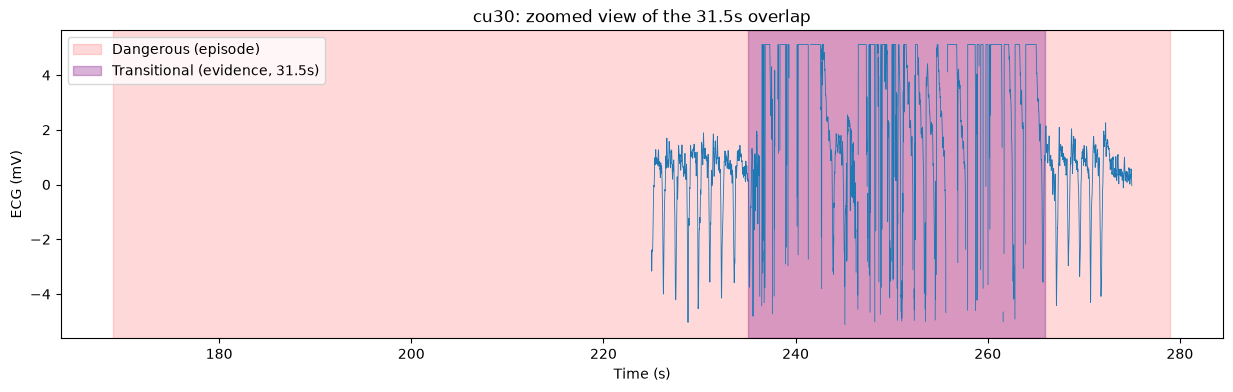

In [25]:
rec = 'cu30'
signal, record_len = load_signal(rec, cudb_path)

zoom_start, zoom_end = int(225*fs), int(275*fs)  # around the 235-266s overlap
plt.figure(figsize=(15, 4))
plt.plot(np.arange(zoom_start, zoom_end)/fs, signal[zoom_start:zoom_end], linewidth=0.6)
plt.axvspan(169, 279, color='red', alpha=0.15, label='Dangerous (episode)')
plt.axvspan(235, 266, color='purple', alpha=0.3, label='Transitional (evidence, 31.5s)')
plt.xlabel('Time (s)')
plt.ylabel('ECG (mV)')
plt.title('cu30: zoomed view of the 31.5s overlap')
plt.legend()
plt.show()


### 14.16 How big are these overlaps generally?

In [26]:
overlap_durations = [dur for _,_,_,_,_,dur in overlap_cases]
overlap_arr = np.array(overlap_durations)
print("Count:", len(overlap_arr))
print("Median:", np.median(overlap_arr))
print("75th/90th/95th percentile:", np.percentile(overlap_arr, [75, 90, 95]))
print("How many are >= 10s:", (overlap_arr >= 10).sum())


Count: 130
Median: 2.324
75th/90th/95th percentile: [4.178  6.8332 8.4058]
How many are >= 10s: 5


### 14.17 Distinguishing a genuine sustained-clipping episode from a brief shock-spike burst
A long overlap could mean the signal is genuinely unreadable throughout, or that it just touches the clipping ceiling briefly a few times (a shock artifact, like Chapter 7). Counting discrete \"touches\" tells the two apart.

In [27]:
rec = 'cu30'
signal, record_len = load_signal(rec, cudb_path)

zoom_start, zoom_end = int(235*fs), int(266*fs)
window = signal[zoom_start:zoom_end]

valid = signal[~np.isnan(signal)]
sig_max = valid.max()
sig_min = valid.min()

# find where the windowed signal touches the ceiling or floor
at_extreme = (window >= sig_max - 0.05) | (window <= sig_min + 0.05)
extreme_indices = np.where(at_extreme)[0]

# group into discrete events (new event if gap > 0.5s)
if len(extreme_indices) > 0:
    breaks = np.where(np.diff(extreme_indices) > int(0.5*fs))[0]
    starts = np.insert(extreme_indices[breaks+1], 0, extreme_indices[0])
    ends = np.append(extreme_indices[breaks], extreme_indices[-1])
    print(f"Number of discrete spike events: {len(starts)}")
    for s, e in zip(starts, ends):
        t_start = (zoom_start + s) / fs
        t_end = (zoom_start + e) / fs
        print(f"  event at {t_start:.1f}s - {t_end:.1f}s (duration {t_end-t_start:.2f}s)")
else:
    print("No extreme-touching samples found")


Number of discrete spike events: 13
  event at 236.5s - 237.3s (duration 0.82s)
  event at 238.1s - 239.3s (duration 1.18s)
  event at 240.2s - 242.9s (duration 2.74s)
  event at 245.1s - 245.1s (duration 0.00s)
  event at 246.5s - 249.5s (duration 2.97s)
  event at 250.0s - 250.8s (duration 0.74s)
  event at 251.3s - 251.5s (duration 0.24s)
  event at 252.5s - 252.7s (duration 0.21s)
  event at 254.7s - 254.8s (duration 0.10s)
  event at 255.8s - 256.8s (duration 0.96s)
  event at 257.9s - 262.2s (duration 4.28s)
  event at 262.9s - 263.3s (duration 0.46s)
  event at 264.0s - 265.0s (duration 1.09s)


### 14.18 Generalizing the spike-event counter into a function

### 14.19 Reclassifying each overlap region using spike-burst evidence

In [28]:
reclassified = []
for rec, ep_s, ep_e, r_s, r_e, dur in overlap_cases:
    signal, _ = load_signal(rec, cudb_path)
    n_events = count_spike_events(signal, r_s, r_e, fs)
    decision = 'Transitional (burst)' if n_events >= 2 else 'Dangerous (single touch)'
    reclassified.append((rec, r_s/fs, r_e/fs, dur, n_events, decision))

for rec, r_s, r_e, dur, n_events, decision in reclassified:
    print(f"{rec}: region {r_s:.0f}-{r_e:.0f}s (dur={dur:.1f}s), spike_events={n_events} -> {decision}")

n_transitional = sum(1 for *_, d in reclassified if 'Transitional' in d)
print(f"\n{n_transitional} of {len(reclassified)} overlap regions reclassified as Transitional")


cu03: region 477-479s (dur=2.0s), spike_events=1 -> Dangerous (single touch)
cu04: region 209-211s (dur=2.3s), spike_events=1 -> Dangerous (single touch)
cu04: region 242-244s (dur=2.0s), spike_events=1 -> Dangerous (single touch)
cu04: region 344-347s (dur=1.6s), spike_events=1 -> Dangerous (single touch)
cu04: region 474-476s (dur=1.5s), spike_events=1 -> Dangerous (single touch)
cu05: region 445-448s (dur=1.5s), spike_events=2 -> Transitional (burst)
cu06: region 280-282s (dur=2.2s), spike_events=1 -> Dangerous (single touch)
cu06: region 332-336s (dur=1.4s), spike_events=2 -> Transitional (burst)
cu08: region 485-488s (dur=3.1s), spike_events=1 -> Dangerous (single touch)
cu09: region 264-266s (dur=2.1s), spike_events=0 -> Dangerous (single touch)
cu09: region 272-275s (dur=3.2s), spike_events=2 -> Transitional (burst)
cu09: region 285-287s (dur=2.0s), spike_events=0 -> Dangerous (single touch)
cu09: region 294-299s (dur=2.1s), spike_events=0 -> Dangerous (single touch)
cu10: regio

### 14.20 CUDB — label-to-class mapping (v2, final)
Combines episodes, evidence-based transitional regions, and the spike-burst override into one interval builder — this supersedes the v1 (`~`-based) version from 14.3.

### 14.21 Checking v2 against cu26 / cu30

In [29]:
for rec in ['cu26', 'cu30']:
    intervals, record_len = cudb_label_intervals_v2(rec, cudb_path, fs)
    pct = class_breakdown_pct(intervals, record_len, fs)
    print(f"{rec}: Normal={pct['Normal']}% Dangerous={pct['Dangerous']}% Transitional={pct['Transitional']}%")
    print(intervals)
    print()


cu26: Normal=67.2% Dangerous=14.5% Transitional=18.3%
[(0, np.int64(36382), 'Normal'), (np.int64(36382), np.int64(50813), 'Dangerous'), (np.int64(50813), np.int64(54298), 'Transitional'), (np.int64(54298), np.int64(54629), 'Normal'), (np.int64(54629), np.int64(62428), 'Transitional'), (np.int64(62428), np.int64(63400), 'Normal'), (np.int64(63400), np.int64(66677), 'Transitional'), (np.int64(66677), np.int64(67110), 'Normal'), (np.int64(67110), np.int64(72768), 'Transitional'), (np.int64(72768), np.int64(79149), 'Normal'), (np.int64(79149), np.int64(79663), 'Transitional'), (np.int64(79663), np.int64(81080), 'Normal'), (np.int64(81080), np.int64(81589), 'Transitional'), (np.int64(81589), np.int64(96471), 'Normal'), (np.int64(96471), np.int64(96974), 'Transitional'), (np.int64(96974), np.int64(118474), 'Normal'), (np.int64(118474), np.int64(119213), 'Transitional'), (np.int64(119213), np.int64(119316), 'Normal'), (np.int64(119316), np.int64(123315), 'Dangerous'), (np.int64(123315), np.in

### 14.22 Visualizing the final v2 classification (cu30, full record)

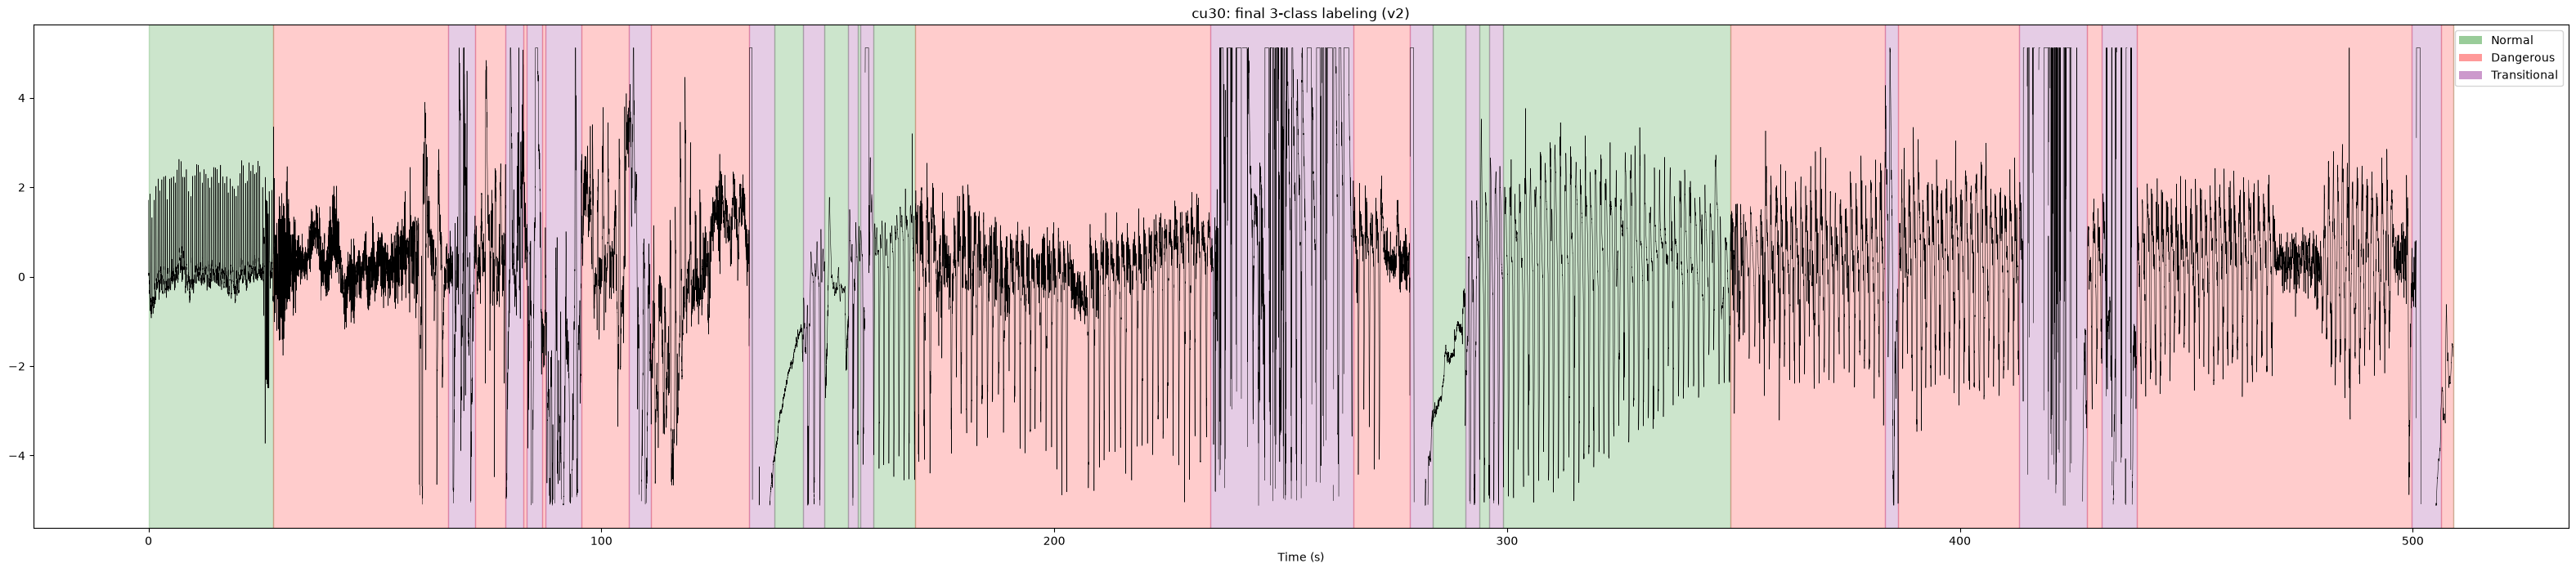

In [30]:
rec = 'cu30'
signal, record_len = load_signal(rec, cudb_path)
intervals, _ = cudb_label_intervals_v2(rec, cudb_path, fs)
time = np.arange(record_len) / fs

colors = {'Normal': 'green', 'Dangerous': 'red', 'Transitional': 'purple'}
plt.figure(figsize=(40, 8))
plt.plot(time, signal, linewidth=0.4, color='black')
for s, e, cls in intervals:
    plt.axvspan(s/fs, e/fs, color=colors[cls], alpha=0.2)
handles = [Patch(facecolor=c, alpha=0.4, label=l) for l, c in colors.items()]
plt.legend(handles=handles)
plt.xlabel('Time (s)')
plt.title(f'{rec}: final 3-class labeling (v2)')
plt.show()


### 14.23 Final CUDB class breakdown across all records, and export

In [31]:
print("--- CUDB final 3-class breakdown per record (v2) ---")
cudb_results = []
for rec in records:
    intervals, record_len = cudb_label_intervals_v2(rec, cudb_path, fs)
    pct = class_breakdown_pct(intervals, record_len, fs)
    cudb_results.append(dict(record=rec, **pct))
    print(f"{rec}: Normal={pct['Normal']}% Dangerous={pct['Dangerous']}% Transitional={pct['Transitional']}%")

cudb_class_df = pd.DataFrame(cudb_results)
cudb_class_df.to_csv(OUTPUT_DIR / 'cudb_class_breakdown.csv', index=False)
print("\n--- Overall averages across all 35 records ---")
print(cudb_class_df[['Normal', 'Dangerous', 'Transitional']].mean().round(1))


--- CUDB final 3-class breakdown per record (v2) ---
cu01: Normal=42.1% Dangerous=57.9% Transitional=0.0%
cu02: Normal=96.8% Dangerous=0.0% Transitional=3.2%
cu03: Normal=90.6% Dangerous=8.5% Transitional=0.9%
cu04: Normal=46.1% Dangerous=53.5% Transitional=0.4%
cu05: Normal=82.0% Dangerous=17.2% Transitional=0.8%
cu06: Normal=72.5% Dangerous=26.9% Transitional=0.6%
cu07: Normal=35.8% Dangerous=64.2% Transitional=0.0%
cu08: Normal=67.8% Dangerous=16.2% Transitional=15.9%
cu09: Normal=86.4% Dangerous=10.6% Transitional=2.9%
cu10: Normal=61.8% Dangerous=36.2% Transitional=2.0%
cu11: Normal=72.9% Dangerous=18.1% Transitional=9.0%
cu12: Normal=61.1% Dangerous=31.8% Transitional=7.1%
cu13: Normal=88.2% Dangerous=7.1% Transitional=4.7%
cu14: Normal=96.5% Dangerous=0.0% Transitional=3.5%
cu15: Normal=71.1% Dangerous=20.2% Transitional=8.7%
cu16: Normal=77.3% Dangerous=22.0% Transitional=0.7%
cu17: Normal=90.1% Dangerous=7.6% Transitional=2.3%
cu18: Normal=93.1% Dangerous=5.3% Transitional=1.6

In [32]:
print("--- VFDB final 3-class breakdown per record ---")
vfdb_results = []
for rec in vfdb_records:
    intervals, record_len = vfdb_label_intervals(rec, vfdb_path)
    if record_len == 0:
        print(f"{rec}: excluded")
        continue
    totals = {'Normal': 0, 'Dangerous': 0, 'Transitional': 0}
    for s, e, cls in intervals:
        totals[cls] += (e - s)
    covered = sum(totals.values())
    total_s = record_len / fs
    pct = {k: round(100*v/fs/total_s, 1) for k, v in totals.items()}
    pct['Excluded (NOISE)'] = round(100*(record_len - covered)/fs/total_s, 1)
    vfdb_results.append(dict(record=rec, **pct))
    print(f"{rec}: Normal={pct['Normal']}% Dangerous={pct['Dangerous']}% "
          f"Transitional={pct['Transitional']}% Excluded={pct['Excluded (NOISE)']}%")

vfdb_class_df = pd.DataFrame(vfdb_results)
vfdb_class_df.to_csv(OUTPUT_DIR / 'vfdb_class_breakdown.csv', index=False)
print("\n--- Overall averages across all included VFDB records ---")
print(vfdb_class_df[['Normal', 'Dangerous', 'Transitional', 'Excluded (NOISE)']].mean().round(1))

--- VFDB final 3-class breakdown per record ---
418: Normal=88.3% Dangerous=11.7% Transitional=0.0% Excluded=0.0%
419: Normal=53.1% Dangerous=9.9% Transitional=0.0% Excluded=36.9%
420: Normal=62.9% Dangerous=13.4% Transitional=0.0% Excluded=23.7%
421: Normal=62.9% Dangerous=16.5% Transitional=0.0% Excluded=20.7%
422: Normal=55.9% Dangerous=34.0% Transitional=0.0% Excluded=10.0%
423: Normal=50.4% Dangerous=22.3% Transitional=0.5% Excluded=26.8%
424: Normal=65.3% Dangerous=7.8% Transitional=13.5% Excluded=13.4%
425: Normal=84.3% Dangerous=1.4% Transitional=0.0% Excluded=14.3%
426: Normal=39.7% Dangerous=37.4% Transitional=0.0% Excluded=22.9%
427: Normal=30.9% Dangerous=42.1% Transitional=27.0% Excluded=0.0%
428: Normal=97.2% Dangerous=2.2% Transitional=0.0% Excluded=0.6%
429: Normal=86.1% Dangerous=4.8% Transitional=0.0% Excluded=9.1%
430: Normal=17.2% Dangerous=69.3% Transitional=11.5% Excluded=2.0%
602: Normal=72.1% Dangerous=18.7% Transitional=0.5% Excluded=8.7%
605: excluded
607: Nor

### 15. Combined Dataset-Wide Class Balance
Duration-weighted totals across both CUDB and VFDB together, rather than averaging per-record percentages.

In [33]:
total_seconds = {'Normal': 0, 'Dangerous': 0, 'Transitional': 0}

for rec in records:  # CUDB
    intervals, _ = cudb_label_intervals_v2(rec, cudb_path, fs)
    for s, e, cls in intervals:
        total_seconds[cls] += (e - s) / fs

for rec in vfdb_records:  # VFDB
    intervals, record_len = vfdb_label_intervals(rec, vfdb_path)
    for s, e, cls in intervals:
        total_seconds[cls] += (e - s) / fs

grand_total = sum(total_seconds.values())
print("--- Combined CUDB + VFDB class balance (duration-weighted) ---")
for cls, secs in total_seconds.items():
    hours = secs / 3600
    print(f"{cls}: {secs:.0f}s ({hours:.2f} hours) — {100*secs/grand_total:.1f}%")

print(f"\nTotal usable signal: {grand_total:.0f}s ({grand_total/3600:.2f} hours)")

--- Combined CUDB + VFDB class balance (duration-weighted) ---
Normal: 38496s (10.69 hours) — 66.5%
Dangerous: 16341s (4.54 hours) — 28.2%
Transitional: 3024s (0.84 hours) — 5.2%

Total usable signal: 57860s (16.07 hours)


### 16. Choosing Window Size From Measured Data-Loss Curves
Collecting every labeled segment's duration per class, then checking how much data each candidate window size would discard — rather than picking a window size arbitrarily.

In [34]:
all_durations = {'Normal': [], 'Dangerous': [], 'Transitional': []}

for rec in records:  # CUDB
    intervals, _ = cudb_label_intervals_v2(rec, cudb_path, fs)
    for s, e, cls in intervals:
        all_durations[cls].append((e - s) / fs)

for rec in vfdb_records:  # VFDB
    intervals, record_len = vfdb_label_intervals(rec, vfdb_path)
    for s, e, cls in intervals:
        all_durations[cls].append((e - s) / fs)

for cls, durs in all_durations.items():
    durs_arr = np.array(durs)
    print(f"--- {cls} ({len(durs_arr)} segments) ---")
    print(f"  min={durs_arr.min():.2f}s, 5th pct={np.percentile(durs_arr,5):.2f}s, "
          f"25th={np.percentile(durs_arr,25):.2f}s, median={np.median(durs_arr):.2f}s, "
          f"75th={np.percentile(durs_arr,75):.2f}s, max={durs_arr.max():.2f}s")
    print(f"  fraction under 10s: {(durs_arr < 10).mean():.1%}")
    print(f"  fraction under 5s: {(durs_arr < 5).mean():.1%}")

--- Normal (496 segments) ---
  min=0.00s, 5th pct=0.24s, 25th=2.08s, median=11.67s, 75th=56.81s, max=1707.31s
  fraction under 10s: 48.0%
  fraction under 5s: 37.1%
--- Dangerous (308 segments) ---
  min=0.36s, 5th pct=1.09s, 25th=2.59s, median=5.81s, 75th=27.67s, max=1196.08s
  fraction under 10s: 60.1%
  fraction under 5s: 45.1%
--- Transitional (275 segments) ---
  min=0.00s, 5th pct=1.97s, 25th=2.02s, median=2.89s, 75th=6.45s, max=566.96s
  fraction under 10s: 83.6%
  fraction under 5s: 66.5%


In [35]:
candidate_sizes = [2, 3, 5, 8, 10]

print("Fraction of segments too short to fit each window size, and % of total class duration lost:")
for cls, durs in all_durations.items():
    durs_arr = np.array(durs)
    print(f"\n{cls}:")
    for w in candidate_sizes:
        too_short = durs_arr < w
        pct_segments_lost = too_short.mean()
        pct_duration_lost = durs_arr[too_short].sum() / durs_arr.sum()
        print(f"  window={w}s: {pct_segments_lost:.1%} of segments too short "
              f"(representing {pct_duration_lost:.1%} of {cls}'s total duration)")

Fraction of segments too short to fit each window size, and % of total class duration lost:

Normal:
  window=2s: 24.2% of segments too short (representing 0.3% of Normal's total duration)
  window=3s: 28.4% of segments too short (representing 0.4% of Normal's total duration)
  window=5s: 37.1% of segments too short (representing 0.9% of Normal's total duration)
  window=8s: 45.4% of segments too short (representing 1.5% of Normal's total duration)
  window=10s: 48.0% of segments too short (representing 1.8% of Normal's total duration)

Dangerous:
  window=2s: 18.8% of segments too short (representing 0.5% of Dangerous's total duration)
  window=3s: 30.2% of segments too short (representing 1.0% of Dangerous's total duration)
  window=5s: 45.1% of segments too short (representing 2.1% of Dangerous's total duration)
  window=8s: 56.2% of segments too short (representing 3.4% of Dangerous's total duration)
  window=10s: 60.1% of segments too short (representing 4.0% of Dangerous's total 

### 17. Choosing Step Size / Overlap
Checking how much overlap actually buys in extra (especially Transitional) windows before picking a value. Overlap is safe here since the train/test split happens at the record level, not the window level.

In [36]:
def total_window_counts(window_s, step_s):
    counts = Counter()
    for rec in records:  # CUDB
        intervals, record_len = cudb_label_intervals_v2(rec, cudb_path, fs)
        for _, _, cls in window_record(intervals, record_len, window_s, step_s, fs):
            counts[cls] += 1
    for rec in vfdb_records:  # VFDB
        intervals, record_len = vfdb_label_intervals(rec, vfdb_path)
        if record_len == 0:
            continue
        for _, _, cls in window_record(intervals, record_len, window_s, step_s, fs):
            counts[cls] += 1
    return counts

for window_s in [2, 5]:
    print(f"\n=== window={window_s}s ===")
    for step_s in [window_s, window_s*0.5, window_s*0.25]:
        counts = total_window_counts(window_s, step_s)
        total = sum(counts.values())
        print(f"  step={step_s}s (overlap={100*(1-step_s/window_s):.0f}%): "
              f"total={total}, Normal={counts['Normal']}, Dangerous={counts['Dangerous']}, Transitional={counts['Transitional']}")


=== window=2s ===
  step=2s (overlap=0%): total=28914, Normal=19231, Dangerous=8171, Transitional=1512
  step=1.0s (overlap=50%): total=57773, Normal=38421, Dangerous=16327, Transitional=3025
  step=0.5s (overlap=75%): total=115523, Normal=76816, Dangerous=32650, Transitional=6057

=== window=5s ===
  step=5s (overlap=0%): total=11541, Normal=7719, Dangerous=3254, Transitional=568
  step=2.5s (overlap=50%): total=23062, Normal=15396, Dangerous=6516, Transitional=1150
  step=1.25s (overlap=75%): total=46155, Normal=30797, Dangerous=13043, Transitional=2315


### 18. Train/Test Split (Record-Level, Stratified)
80/20 split by whole record, stratified by database and the two signal-quality flags (`needs_special_handling`, `unclosed`), so test isn't accidentally all-clean or all-messy records.

In [37]:
# build the stratification key from what we already know about each record
split_df = summary_df[~summary_df['record'].isin(EXCLUDED_RECORDS)].copy()
split_df['stratum'] = split_df['db'] + '_special' + split_df['needs_special_handling'].astype(str) + '_unclosed' + split_df['unclosed'].astype(str)

print("Stratum sizes:")
print(split_df['stratum'].value_counts())

random.seed(RANDOM_SEED)
train_records, test_records = [], []

for stratum, group in split_df.groupby('stratum'):
    recs = list(group['record'])
    random.shuffle(recs)
    n_test = max(1, round(len(recs) * TEST_FRACTION)) if len(recs) > 1 else 0
    test_records.extend(recs[:n_test])
    train_records.extend(recs[n_test:])

print(f"\nTrain: {len(train_records)} records, Test: {len(test_records)} records")
print("Test set:", sorted(test_records))

# sanity check: db mix should be roughly preserved in both splits
train_db_counts = split_df[split_df['record'].isin(train_records)]['db'].value_counts()
test_db_counts = split_df[split_df['record'].isin(test_records)]['db'].value_counts()
print("\nTrain db mix:", dict(train_db_counts))
print("Test db mix:", dict(test_db_counts))

Stratum sizes:
stratum
CUDB_specialFalse_unclosedFalse    18
VFDB_specialFalse_unclosedFalse    11
CUDB_specialTrue_unclosedFalse      9
CUDB_specialFalse_unclosedTrue      5
VFDB_specialTrue_unclosedFalse      5
VFDB_specialFalse_unclosedTrue      5
CUDB_specialTrue_unclosedTrue       3
Name: count, dtype: int64

Train: 44 records, Test: 12 records
Test set: ['425', '429', '607', '615', 'cu05', 'cu12', 'cu15', 'cu17', 'cu18', 'cu19', 'cu26', 'cu34']

Train db mix: {'CUDB': np.int64(27), 'VFDB': np.int64(17)}
Test db mix: {'CUDB': np.int64(8), 'VFDB': np.int64(4)}


### 19. Building the Final Windowed Datasets
Applying the chosen window sizes (2s, 5s) and step sizes (75% overlap) to the train/test record split, and saving the resulting window index to CSV.

In [38]:
for window_s, step_s in WINDOW_CONFIGS.items():  # current project configuration
    print(f"\n=== window={window_s}s, step={step_s}s (75% overlap) ===")
    train_df = build_windowed_dataset(train_records, cudb_set, window_s, step_s, cudb_path, vfdb_path, fs, MIN_MAJORITY)
    test_df = build_windowed_dataset(test_records, cudb_set, window_s, step_s, cudb_path, vfdb_path, fs, MIN_MAJORITY)
    print("Train:", len(train_df), dict(train_df['label'].value_counts()))
    print("Test:", len(test_df), dict(test_df['label'].value_counts()))
    train_df.to_csv(OUTPUT_DIR / f'windows_{window_s}s_train.csv', index=False)
    test_df.to_csv(OUTPUT_DIR / f'windows_{window_s}s_test.csv', index=False)


=== window=2s, step=0.5s (75% overlap) ===
Train: 91609 {'Normal': np.int64(60140), 'Dangerous': np.int64(26236), 'Transitional': np.int64(5233)}
Test: 23914 {'Normal': np.int64(16676), 'Dangerous': np.int64(6414), 'Transitional': np.int64(824)}

=== window=5s, step=1.25s (75% overlap) ===
Train: 36604 {'Normal': np.int64(24094), 'Dangerous': np.int64(10483), 'Transitional': np.int64(2027)}
Test: 9551 {'Normal': np.int64(6703), 'Dangerous': np.int64(2560), 'Transitional': np.int64(288)}


## 20. NaN Gap Imputation Investigation
Revisiting the NaN gaps found in Notebook 01, now to decide how (or whether) to fill them rather than just dropping them from feature extraction.

In [39]:
from src.annotations import find_nan_blocks
from src.io import load_signal
from src.config import CUDB_PATH

all_block_durations = []
for rec in records:
    signal, _ = load_signal(rec, CUDB_PATH)
    nan_blocks = find_nan_blocks(signal)
    for s, e in nan_blocks:
        all_block_durations.append((e - s) / 250)

durs = np.array(all_block_durations)
print("Number of NaN blocks:", len(durs))
print("Median duration (s):", np.median(durs))
print("25th/75th/90th/95th percentile (s):", np.percentile(durs, [25, 75, 90, 95]))
print("Max duration (s):", durs.max())
print("Fraction under 0.5s:", (durs < 0.5).mean())
print("Fraction under 1s:", (durs < 1).mean())
print("Fraction under 2s:", (durs < 2).mean())

Number of NaN blocks: 758
Median duration (s): 0.052
25th/75th/90th/95th percentile (s): [0.016  0.16   0.536  0.8956]
Max duration (s): 4.792
Fraction under 0.5s: 0.8984168865435356
Fraction under 1s: 0.9630606860158312
Fraction under 2s: 0.9907651715039578


### 21. Comparing Interpolation Methods: PCHIP vs. Akima
Fitting both on a short, medium, and long real gap to see how they actually differ, rather than deciding from theory alone.

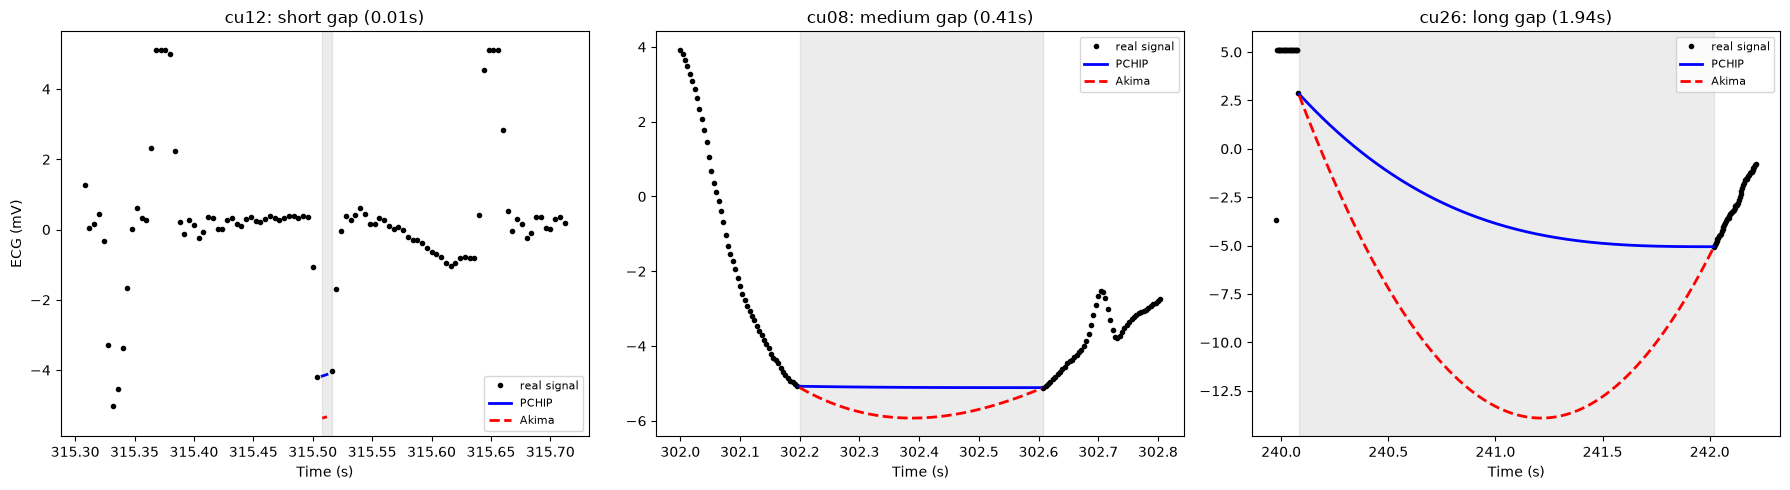

In [40]:
from scipy.interpolate import PchipInterpolator, Akima1DInterpolator
from src.annotations import find_nan_blocks
from src.io import load_signal
from src.config import CUDB_PATH

fs = 250

all_gaps = []
for rec in records:
    signal, _ = load_signal(rec, CUDB_PATH)
    for s, e in find_nan_blocks(signal):
        dur = (e - s) / fs
        all_gaps.append((rec, s, e, dur))

all_gaps.sort(key=lambda x: x[3])
short_gap = all_gaps[len(all_gaps)//10]
medium_gap = [g for g in all_gaps if 0.4 < g[3] < 0.6][0]
long_gap = [g for g in all_gaps if 1.3 < g[3] < 2.0][-1]

examples = [('short', short_gap), ('medium', medium_gap), ('long', long_gap)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for col, (label, (rec, gap_s, gap_e, dur)) in enumerate(examples):
    signal, _ = load_signal(rec, CUDB_PATH)

    context = 50
    fit_start = max(0, gap_s - context)
    fit_end = min(len(signal), gap_e + context)

    x_known = np.concatenate([np.arange(fit_start, gap_s), np.arange(gap_e, fit_end)])
    y_known = np.concatenate([signal[fit_start:gap_s], signal[gap_e:fit_end]])

    # drop any NaN that leaked in from a neighboring gap within the context window
    valid_mask = ~np.isnan(y_known)
    x_known, y_known = x_known[valid_mask], y_known[valid_mask]

    x_gap = np.arange(gap_s, gap_e)

    pchip_fit = PchipInterpolator(x_known, y_known)(x_gap)
    akima_fit = Akima1DInterpolator(x_known, y_known)(x_gap)

    ax = axes[col]
    ax.plot(x_known/fs, y_known, 'o', markersize=3, color='black', label='real signal')
    ax.plot(x_gap/fs, pchip_fit, color='blue', linewidth=2, label='PCHIP')
    ax.plot(x_gap/fs, akima_fit, color='red', linewidth=2, linestyle='--', label='Akima')
    ax.axvspan(gap_s/fs, gap_e/fs, color='gray', alpha=0.15)
    ax.set_title(f"{rec}: {label} gap ({dur:.2f}s)")
    ax.set_xlabel('Time (s)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('ECG (mV)')
plt.tight_layout()
plt.show()

### 22. Testing a Clipping Safety Net for Akima's Overshoot
Akima can badly overshoot on longer gaps (confirmed on cu26 — fabricated a value beyond the recorder's physical range). Testing whether clamping the output to the record's observed min/max fixes this without losing Akima's advantage on shorter gaps.

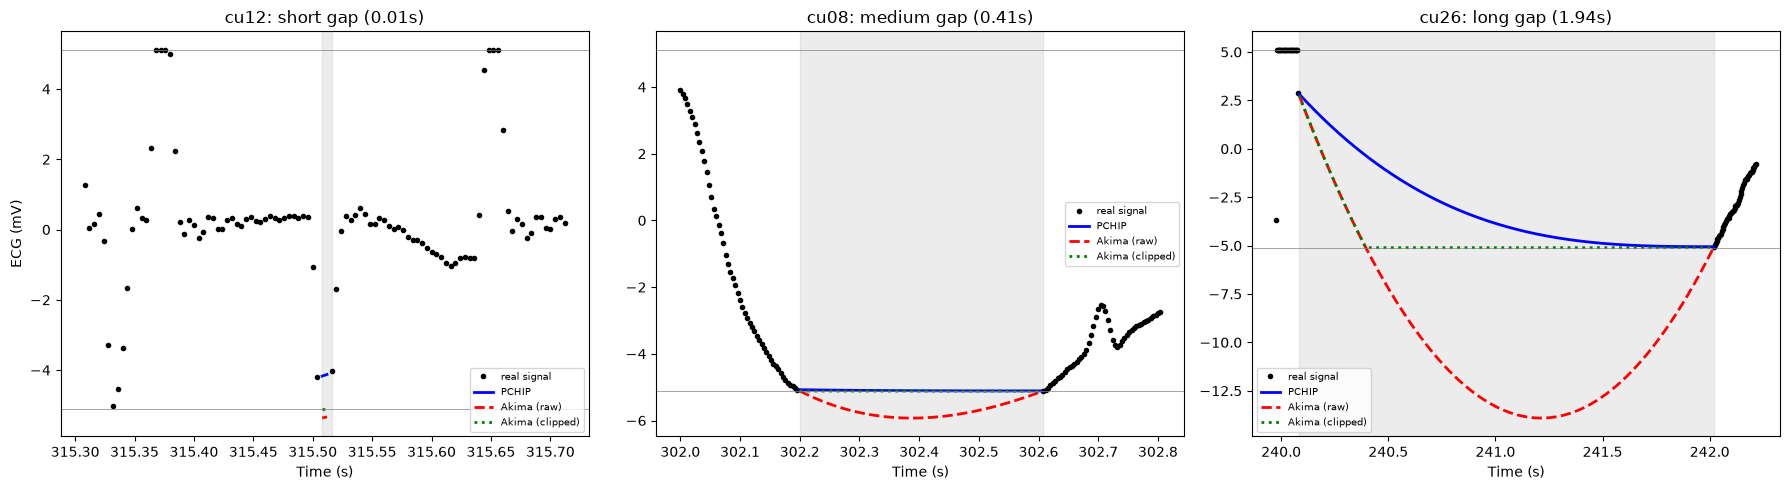

In [41]:
def clip_to_range(values, sig_min, sig_max):
    return np.clip(values, sig_min, sig_max)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for col, (label, (rec, gap_s, gap_e, dur)) in enumerate(examples):
    signal, _ = load_signal(rec, CUDB_PATH)
    valid_full = signal[~np.isnan(signal)]
    sig_min, sig_max = valid_full.min(), valid_full.max()

    context = 50
    fit_start = max(0, gap_s - context)
    fit_end = min(len(signal), gap_e + context)

    x_known = np.concatenate([np.arange(fit_start, gap_s), np.arange(gap_e, fit_end)])
    y_known = np.concatenate([signal[fit_start:gap_s], signal[gap_e:fit_end]])
    valid_mask = ~np.isnan(y_known)
    x_known, y_known = x_known[valid_mask], y_known[valid_mask]

    x_gap = np.arange(gap_s, gap_e)

    pchip_fit = PchipInterpolator(x_known, y_known)(x_gap)
    akima_fit = Akima1DInterpolator(x_known, y_known)(x_gap)
    akima_clipped = clip_to_range(akima_fit, sig_min, sig_max)

    ax = axes[col]
    ax.plot(x_known/fs, y_known, 'o', markersize=3, color='black', label='real signal')
    ax.plot(x_gap/fs, pchip_fit, color='blue', linewidth=2, label='PCHIP')
    ax.plot(x_gap/fs, akima_fit, color='red', linewidth=2, linestyle='--', label='Akima (raw)')
    ax.plot(x_gap/fs, akima_clipped, color='green', linewidth=2, linestyle=':', label='Akima (clipped)')
    ax.axhline(sig_min, color='gray', linewidth=0.5, linestyle='-')
    ax.axhline(sig_max, color='gray', linewidth=0.5, linestyle='-')
    ax.axvspan(gap_s/fs, gap_e/fs, color='gray', alpha=0.15)
    ax.set_title(f"{rec}: {label} gap ({dur:.2f}s)")
    ax.set_xlabel('Time (s)')
    ax.legend(fontsize=7)
axes[0].set_ylabel('ECG (mV)')
plt.tight_layout()
plt.show()

### 23. Testing Whether NaN Gaps Are Bordered by Clipping Extremes
Hypothesis: NaN gaps mostly occur because the true signal exceeded even the recorder's clipping ceiling, not from random dropout — checking whether the samples immediately before/after each gap are already at the extreme.

In [42]:
from src.annotations import find_nan_blocks
from src.io import load_signal
from src.config import CUDB_PATH

fs = 250
border_context = 5  # samples to check right before/after the gap
tol_frac = 0.05  # "near extreme" = within 5% of the record's own range

results = []
for rec in records:
    signal, _ = load_signal(rec, CUDB_PATH)
    valid = signal[~np.isnan(signal)]
    sig_min, sig_max = valid.min(), valid.max()
    tol = tol_frac * (sig_max - sig_min)

    for s, e in find_nan_blocks(signal):
        before = signal[max(0, s-border_context):s]
        after = signal[e:min(len(signal), e+border_context)]
        before = before[~np.isnan(before)]
        after = after[~np.isnan(after)]

        before_extreme = len(before) > 0 and (np.any(before >= sig_max - tol) or np.any(before <= sig_min + tol))
        after_extreme = len(after) > 0 and (np.any(after >= sig_max - tol) or np.any(after <= sig_min + tol))

        results.append((rec, s, e, (e-s)/fs, before_extreme, after_extreme))

results_df = pd.DataFrame(results, columns=['record','start','end','duration','before_extreme','after_extreme'])
results_df['either_extreme'] = results_df['before_extreme'] | results_df['after_extreme']
results_df['both_extreme'] = results_df['before_extreme'] & results_df['after_extreme']

print("Total NaN gaps:", len(results_df))
print("Bordered by extreme on at least one side:", results_df['either_extreme'].mean())
print("Bordered by extreme on both sides:", results_df['both_extreme'].mean())
print("Calm on both sides:", (~results_df['either_extreme']).mean())

Total NaN gaps: 758
Bordered by extreme on at least one side: 0.8944591029023746
Bordered by extreme on both sides: 0.6240105540897097
Calm on both sides: 0.10554089709762533


### 24. Validating Clipped-Akima on Shorter Clipping-Bordered Gaps
Checking whether clipped-Akima reliably stays pinned at the boundary on short clipping-bordered gaps, or drifts through an unsupported calmer middle — this decides whether clipping alone is a safe stand-in for an explicit hold-at-extreme rule.

   record  start    end  duration  before_extreme  after_extreme  \
10   cu02  99181  99278     0.388            True           True   
12   cu02  99306  99419     0.452            True           True   
13   cu02  99449  99542     0.372            True           True   
33   cu08  75550  75652     0.408            True           True   

    either_extreme  both_extreme  
10            True          True  
12            True          True  
13            True          True  
33            True          True  


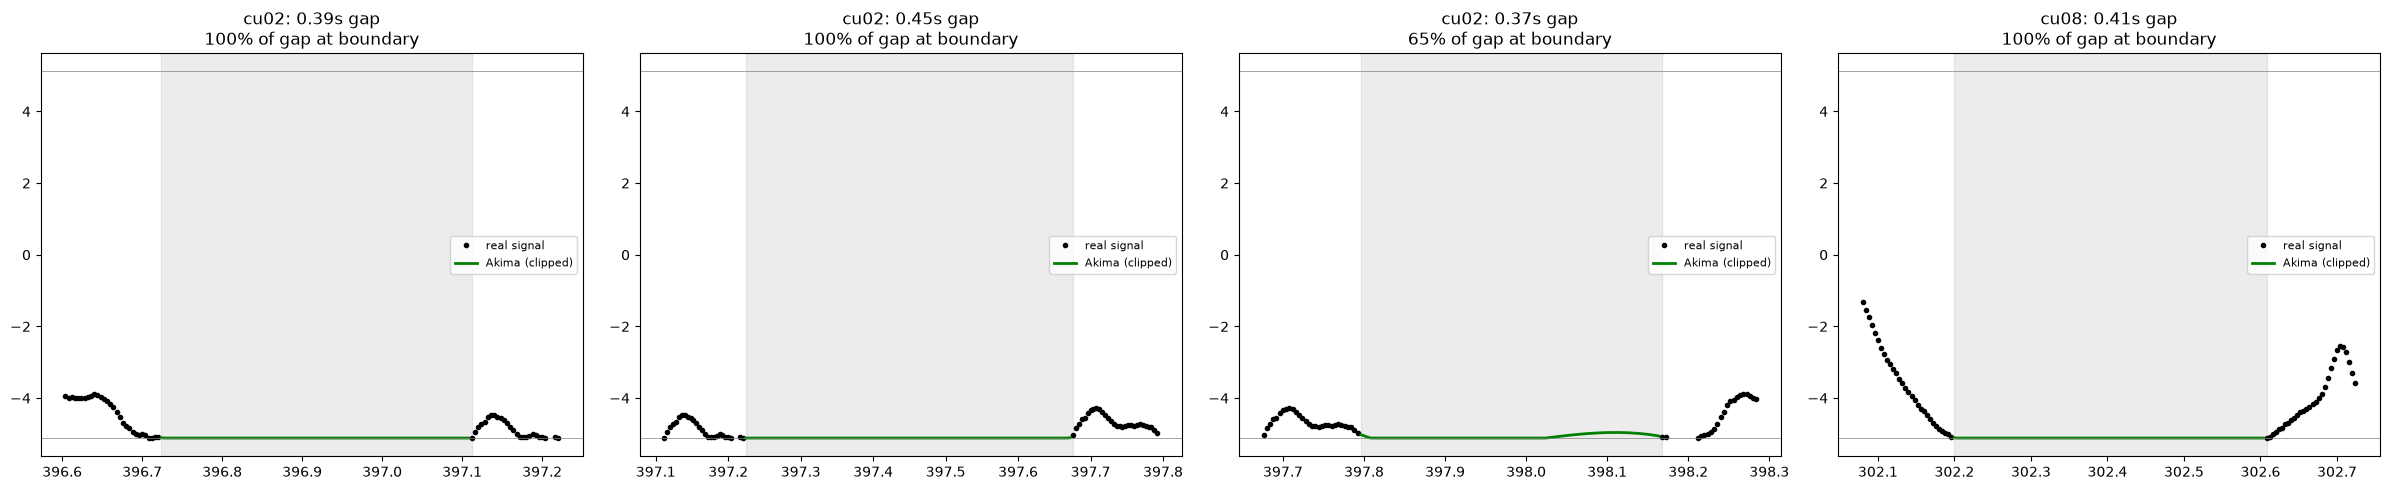

In [43]:
short_extreme_gaps = results_df[
    (results_df['both_extreme']) & (results_df['duration'] >= 0.3) & (results_df['duration'] <= 1.0)
].head(4)

print(short_extreme_gaps)

fig, axes = plt.subplots(1, len(short_extreme_gaps), figsize=(6*len(short_extreme_gaps), 5))
for col, (_, row) in enumerate(short_extreme_gaps.iterrows()):
    rec, gap_s, gap_e = row['record'], row['start'], row['end']
    signal, _ = load_signal(rec, CUDB_PATH)
    valid_full = signal[~np.isnan(signal)]
    sig_min, sig_max = valid_full.min(), valid_full.max()

    context = 30
    fit_start = max(0, gap_s - context)
    fit_end = min(len(signal), gap_e + context)
    x_known = np.concatenate([np.arange(fit_start, gap_s), np.arange(gap_e, fit_end)])
    y_known = np.concatenate([signal[fit_start:gap_s], signal[gap_e:fit_end]])
    valid_mask = ~np.isnan(y_known)
    x_known, y_known = x_known[valid_mask], y_known[valid_mask]

    x_gap = np.arange(gap_s, gap_e)
    akima_fit = Akima1DInterpolator(x_known, y_known)(x_gap)
    akima_clipped = np.clip(akima_fit, sig_min, sig_max)

    # how much of the gap does the clipped version actually spend AT the boundary?
    at_boundary = np.mean((akima_clipped >= sig_max - 0.05) | (akima_clipped <= sig_min + 0.05))

    ax = axes[col]
    ax.plot(x_known/fs, y_known, 'o', markersize=3, color='black', label='real signal')
    ax.plot(x_gap/fs, akima_clipped, color='green', linewidth=2, label='Akima (clipped)')
    ax.axhline(sig_min, color='gray', linewidth=0.5)
    ax.axhline(sig_max, color='gray', linewidth=0.5)
    ax.axvspan(gap_s/fs, gap_e/fs, color='gray', alpha=0.15)
    ax.set_title(f"{rec}: {row['duration']:.2f}s gap\n{at_boundary:.0%} of gap at boundary")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()